In [24]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from taln.taln_aln import norm_text, tokenize


def nd(arr):
    return np.asarray(arr).reshape(-1)


def yex(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]

    ax.plot(lims, lims, c="k", alpha=0.75, zorder=0)
    ax.set(**{"aspect": "equal", "xlim": lims, "ylim": lims})
    return ax


fsize = 15
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = "retina"


In [25]:
# Bio BOAT inputs
# Expect input files at: tests/papers/*/boat.json

DATA_DIR = (Path("..").resolve() / "data")
PAPERS_DIR = (Path("..").resolve() / "tests" / "papers")


def list_bioboat_paths(papers_dir=PAPERS_DIR, limit=None):
    paths = sorted(Path(papers_dir).glob("*/boat.json"))
    if limit is not None:
        paths = paths[: int(limit)]
    return paths


# For now you can keep this small while you're still generating files.
LIMIT_FILES = None  # set to None to use all available

bioboat_paths = list_bioboat_paths(limit=LIMIT_FILES)
len(bioboat_paths), bioboat_paths[:3]


(51,
 [PosixPath('/Users/sinabooeshaghi/projects/taln/tests/papers/00396a9a-780e-1014-a23f-b0246bd365b2/boat.json'),
  PosixPath('/Users/sinabooeshaghi/projects/taln/tests/papers/09c14dbf-7690-1014-ab11-e88a9b0a1db1/boat.json'),
  PosixPath('/Users/sinabooeshaghi/projects/taln/tests/papers/0a8ee49f-73aa-1014-827f-9336b55f8834/boat.json')])

In [26]:
def load_bioboat_records(paths):
    records = []

    for path in paths:
        with open(path, "r", encoding="utf-8") as f:
            obj = json.load(f)

        if isinstance(obj, dict) and "records" in obj:
            rows = obj["records"]
        elif isinstance(obj, list):
            rows = obj
        else:
            raise ValueError(f"Unexpected JSON format in {path}")

        paper_id = Path(path).parent.name

        for r in rows:
            source = r["source"]
            target = r["target"]
            starts = r["idx_start"]

            if isinstance(starts, int):
                starts = [starts]

            for idx_start in starts:
                records.append(
                    {
                        "paper_id": paper_id,
                        "source": source,
                        "target": target,
                        "idx_start": int(idx_start),
                    }
                )

    return records


raw_records = load_bioboat_records(bioboat_paths)
len(raw_records), raw_records[0].keys()


(5840, dict_keys(['paper_id', 'source', 'target', 'idx_start']))

In [27]:
def keep_naive_matches(records):
    # Match the rule used in make_ds.ipynb: keep only cases where idx_start
    # points to the first occurrence of target in source.
    kept = []

    for r in records:
        source = r["source"]
        target = r["target"]
        idx_start = r["idx_start"]

        if not isinstance(source, str) or not isinstance(target, str):
            continue
        if not isinstance(idx_start, int) or idx_start < 0:
            continue

        if source.find(target) != idx_start:
            continue

        kept.append(r)

    return kept


def dedupe_records(records):
    seen = set()
    out = []

    for r in records:
        key = (r["source"], r["target"], r["idx_start"])
        if key in seen:
            continue
        seen.add(key)
        out.append(r)

    return out


def add_row_id(records):
    out = []

    for i, r in enumerate(records):
        rr = dict(r)
        rr["row_id"] = i
        out.append(rr)

    return out


def shift_records(records):
    out = []

    for r in records:
        rr = dict(r)
        idx_start = rr["idx_start"]
        source = rr["source"]

        rr["idx_start_orig"] = idx_start
        rr["target_orig"] = rr["target"]

        if idx_start > 0 and source[idx_start - 1] == " ":
            rr["target"] = " " + rr["target"]
            rr["idx_start"] = idx_start - 1

        out.append(rr)

    return out


def build_boat_frames(clean_records, shifted_records, min_target_ws_tokens=2):
    clean_df = pd.DataFrame(clean_records)
    shifted_df = pd.DataFrame(shifted_records)

    # Apply the same target length filter on the shifted (token) side, then keep
    # the corresponding clean rows by row_id.
    shifted_df = shifted_df[shifted_df["target"].str.split().str.len() > min_target_ws_tokens]
    keep_ids = set(shifted_df["row_id"].tolist())
    clean_df = clean_df[clean_df["row_id"].isin(keep_ids)]

    drop_cols = ["paper_id"]

    tdf = (
        shifted_df.drop(columns=drop_cols, errors="ignore")
        .groupby(["source", "target"])["idx_start"]
        .apply(set)
        .reset_index()
    )

    wdf = (
        clean_df.drop(columns=drop_cols, errors="ignore")
        .groupby(["source", "target"])["idx_start"]
        .apply(set)
        .reset_index()
    )

    return wdf, tdf, clean_df.reset_index(drop=True), shifted_df.reset_index(drop=True)


In [28]:
def build_bioboat(paths):
    n_files = len(paths)
    raw_records = load_bioboat_records(paths)
    n_raw = len(raw_records)

    clean_records = keep_naive_matches(raw_records)
    n_naive = len(clean_records)

    clean_records = dedupe_records(clean_records)
    n_dedup = len(clean_records)

    def len_preserved(r):
        return len(norm_text(r["source"])) == len(r["source"]) and len(norm_text(r["target"])) == len(r["target"])

    clean_records = [r for r in clean_records if len_preserved(r)]
    n_len_ok = len(clean_records)

    clean_records = add_row_id(clean_records)
    shifted_records = shift_records(clean_records)

    n_shifted = sum(r["idx_start"] != r["idx_start_orig"] for r in shifted_records)

    wdf, tdf, clean_df, shifted_df = build_boat_frames(
        clean_records,
        shifted_records,
        min_target_ws_tokens=2,
    )

    return {
        "n_files": n_files,
        "n_raw": n_raw,
        "n_naive": n_naive,
        "n_dedup": n_dedup,
        "n_len_ok": n_len_ok,
        "n_shifted": n_shifted,
        "clean_df": clean_df,
        "shifted_df": shifted_df,
        "wdf": wdf,
        "tdf": tdf,
    }


bio = build_bioboat(bioboat_paths)

wdf_bio, tdf_bio = bio["wdf"], bio["tdf"]
(bio["n_files"], wdf_bio.shape, tdf_bio.shape)


(51, (5316, 3), (5316, 3))

In [29]:
def find_span_mismatches(df, source_col="source", target_col="target", idx_col="idx_start"):
    bad = []

    for i, r in df.iterrows():
        source = r[source_col]
        target = r[target_col]
        idx_start = r[idx_col]

        if source[idx_start : idx_start + len(target)] != target:
            bad.append(i)

    return bad


def check_shift_rule(shifted_df):
    shifted = shifted_df[shifted_df["idx_start"] != shifted_df["idx_start_orig"]]
    if shifted.shape[0] == 0:
        return True

    def row_ok(r):
        idx0 = r["idx_start_orig"]
        if idx0 <= 0:
            return False
        if r["source"][idx0 - 1] != " ":
            return False
        if r["idx_start"] != idx0 - 1:
            return False
        return r["target"] == " " + r["target_orig"]

    return shifted.apply(row_ok, axis=1).all()


def summarize_checks(bio_obj):
    clean_df = bio_obj["clean_df"]
    shifted_df = bio_obj["shifted_df"]

    clean_bad = find_span_mismatches(clean_df)
    shifted_bad = find_span_mismatches(shifted_df)

    return {
        "n_files": bio_obj["n_files"],
        "n_raw": bio_obj["n_raw"],
        "n_naive": bio_obj["n_naive"],
        "n_dedup": bio_obj["n_dedup"],
        "n_len_ok": bio_obj["n_len_ok"],
        "n_shifted": bio_obj["n_shifted"],
        "n_clean_rows": int(clean_df.shape[0]),
        "n_shift_rows": int(shifted_df.shape[0]),
        "n_clean_span_bad": int(len(clean_bad)),
        "n_shift_span_bad": int(len(shifted_bad)),
        "shift_rule_ok": bool(check_shift_rule(shifted_df)),
    }


checks = pd.DataFrame({"bioboat": summarize_checks(bio)}).T
checks


,n_files,n_raw,n_naive,n_dedup,n_len_ok,n_shifted,n_clean_rows,n_shift_rows,n_clean_span_bad,n_shift_span_bad,shift_rule_ok
bioboat,51,5840,5837,5837,5337,4546,5316,5316,0,0,True


In [30]:
def summarize_texts(texts):
    chars = texts.str.len()
    ws = texts.apply(lambda s: len(s.split()))
    toks = texts.apply(lambda s: len(tokenize(s)[0]))

    return {
        "Char/Sample": chars.mean(),
        "WS/Sample": ws.mean(),
        "Tok/Sample": toks.mean(),
        "N Samples": texts.shape[0],
    }


def boat_summary_table(df):
    sources = pd.Series(df["source"].unique())
    targets = pd.Series(df["target"].unique())

    table = pd.DataFrame(
        {
            "source": summarize_texts(sources),
            "target": summarize_texts(targets),
        }
    ).T

    return table[["N Samples", "Char/Sample", "WS/Sample", "Tok/Sample"]]


summary = boat_summary_table(tdf_bio)
summary


,N Samples,Char/Sample,WS/Sample,Tok/Sample
source,2700.0,483.814444,72.702963,105.613704
target,5312.0,97.005648,14.326242,19.813441


In [31]:
tdf_bio.shape

(5316, 3)

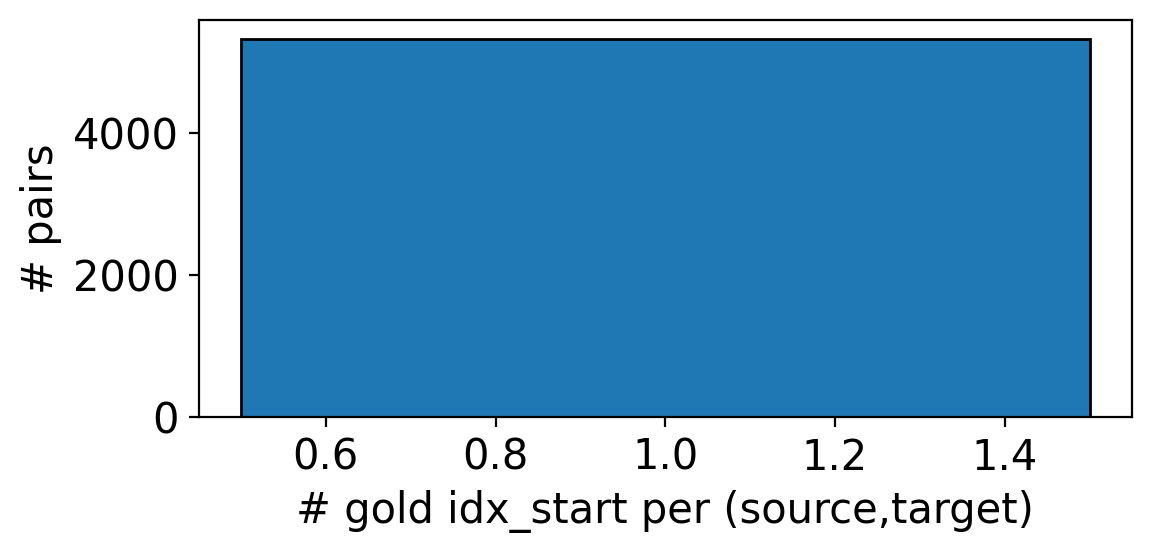

n_pairs            5316.0
n_multimap            0.0
frac_multimap         0.0
max_gold_starts       1.0
dtype: float64

In [32]:
# Multi-mapping by gold idx_start set size (per (source,target) row)

n_gold = tdf_bio["idx_start"].apply(len)

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(n_gold, bins=np.arange(1, int(n_gold.max()) + 2) - 0.5, edgecolor="black")
ax.set(xlabel="# gold idx_start per (source,target)", ylabel="# pairs")
plt.tight_layout()
plt.show()

pd.Series(
    {
        "n_pairs": int(tdf_bio.shape[0]),
        "n_multimap": int((n_gold > 1).sum()),
        "frac_multimap": float((n_gold > 1).mean()),
        "max_gold_starts": int(n_gold.max()),
    }
)


In [33]:
def to_jsonable_starts(df):
    out = df.copy()
    out["idx_start"] = out["idx_start"].apply(lambda s: sorted(list(s)))
    return out


def write_bioboat_files(data_dir=DATA_DIR):
    data_dir = Path(data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)

    exports = {
        "bioboat.tdf.json": to_jsonable_starts(tdf_bio),
        "bioboat.wdf.json": to_jsonable_starts(wdf_bio),
    }

    for name, df in exports.items():
        path = data_dir / name
        with open(path, "w", encoding="utf-8") as f:
            json.dump(df.to_dict(orient="records"), f)

    return {k: str(Path(data_dir) / k) for k in exports}


written = write_bioboat_files()
written


{'bioboat.tdf.json': '/Users/sinabooeshaghi/projects/taln/data/bioboat.tdf.json',
 'bioboat.wdf.json': '/Users/sinabooeshaghi/projects/taln/data/bioboat.wdf.json'}

In [21]:
# Loader snippet (drop-in for benchmark/ablate notebooks)
#
# tdf = pd.read_json(DATA_DIR / "bioboat.tdf.json", orient="records")
# wdf = pd.read_json(DATA_DIR / "bioboat.wdf.json", orient="records")
# tdf["idx_start"] = tdf["idx_start"].apply(set)
# wdf["idx_start"] = wdf["idx_start"].apply(set)
